In [1]:
import pandas as pd
import numpy as np

# 1. Orijinal veriyi yükle (Dosya adının doğru olduğundan emin ol)
df_orijinal = pd.read_csv("Gaming and Mental Health.csv")

def veriyi_rastgele_kirlet(data, eksik_oran=0.15):
    df_kirli = data.copy()
    toplam_satir = len(df_kirli)
    
    # A. RASTGELE EKSİK VERİ (NaN) EKLEME 
    for col in df_kirli.columns:
        # Her satır için rastgele sayı üretir, %15 ihtimalle o hücreyi siler
        mask = np.random.rand(toplam_satir) < eksik_oran
        df_kirli.loc[mask, col] = np.nan
        
    # B. SAYISAL SÜTUNLARA UÇ DEĞER (OUTLIER) EKLEME
    sayisal_sutunlar = df_kirli.select_dtypes(include=[np.number]).columns
    for col in sayisal_sutunlar:
        # 1000 satır içinden TAMAMEN RASTGELE 50 satır seçer
        rastgele_satirlar = np.random.choice(df_kirli.index, size=50, replace=False)
        # Seçtiği satırlara, o sütundaki en büyük sayının 10 katını yazar
        df_kirli.loc[rastgele_satirlar, col] = df_kirli[col].max() * 10
            
    # C. KATEGORİK (YAZI) SÜTUNLARA YAZIM HATASI EKLEME
    kategorik_sutunlar = df_kirli.select_dtypes(include=['object']).columns
    for col in kategorik_sutunlar:
        # TAMAMEN RASTGELE 40 satır seçer
        rastgele_satirlar = np.random.choice(df_kirli.index, size=40, replace=False)
        # Kelimeleri bozup anlamsız bir veri girer
        df_kirli.loc[rastgele_satirlar, col] = 'BOZUK_VERI_999'

    # D. BOOLEAN (MANTIKSAL) SÜTUNLARDAKİ HATALARI ÖNLEME
    # Verideki True/False (bool) sütunlarını otomatik bulur
    bool_sutunlar = data.select_dtypes(include=['bool']).columns
    for col in bool_sutunlar:
        # Boş olanları (NaN) numpy ile güvenlice False yapar ve formatı kilitler
        df_kirli[col] = np.where(df_kirli[col].isna(), False, df_kirli[col]).astype(bool)
            
    return df_kirli

# 2. Fonksiyonu çalıştır
df_kirli = veriyi_rastgele_kirlet(df_orijinal, eksik_oran=0.15)

# 3. Kirli veriyi bilgisayarına kaydet
df_kirli.to_csv("Gaming_and_Mental_Health_KIRLI.csv", index=False)

print("İşlem Başarılı! Veri %15 oranında rastgele bozuldu, uç değerler eklendi ve Boolean uyumsuzlukları giderildi.")
print("\nOluşan Boş (NaN) Veri Sayıları:")
print(df_kirli.isnull().sum())

İşlem Başarılı! Veri %15 oranında rastgele bozuldu, uç değerler eklendi ve Boolean uyumsuzlukları giderildi.

Oluşan Boş (NaN) Veri Sayıları:
record_id                           131
age                                 129
gender                              141
daily_gaming_hours                  144
game_genre                          150
primary_game                        168
gaming_platform                     140
sleep_hours                         166
sleep_quality                       145
sleep_disruption_frequency          158
academic_work_performance           146
grades_gpa                          333
work_productivity_score             405
mood_state                          141
mood_swing_frequency                130
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                    168
exercise_hours_wee

C:\Users\Harun\AppData\Local\Temp\ipykernel_13540\918112348.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_kirli.loc[mask, col] = np.nan
C:\Users\Harun\AppData\Local\Temp\ipykernel_13540\918112348.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_kirli.loc[mask, col] = np.nan
C:\Users\Harun\AppData\Local\Temp\ipykernel_13540\918112348.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_kirli.loc[mask, col] = np.nan
C:\Users\Harun\AppData\Local\Temp\

--- ADIM 2: KİRLİ VERİNİN KEŞİFÇİ VERİ ANALİZİ (EDA) ---


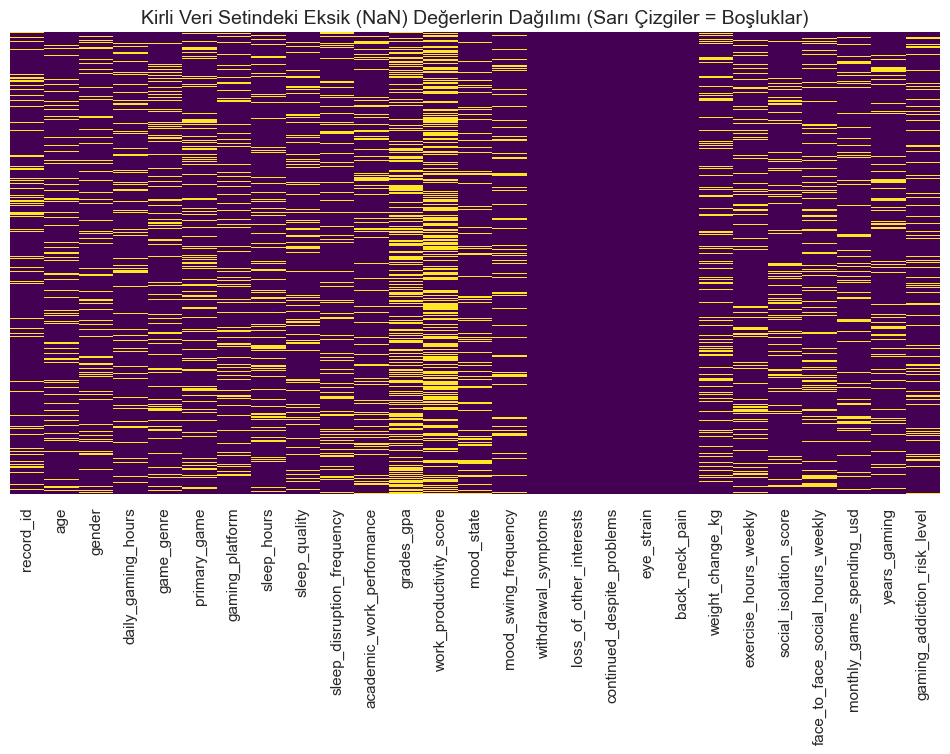

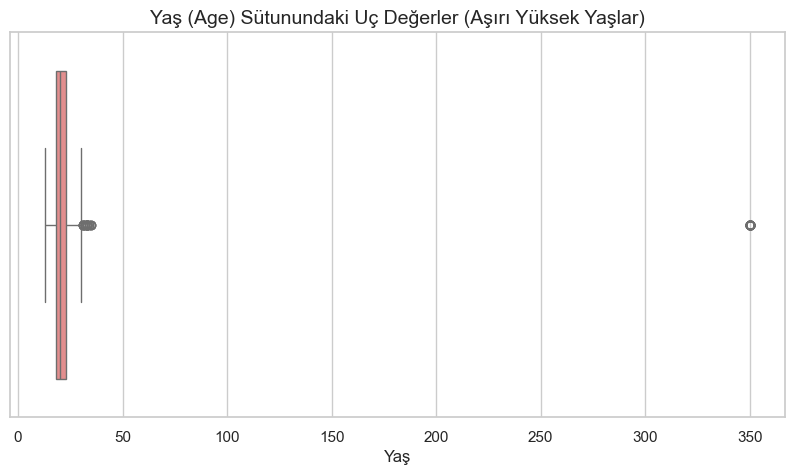

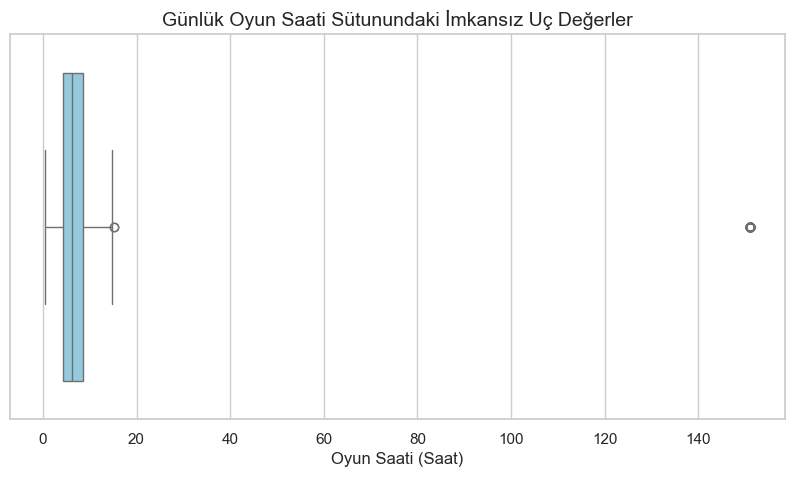


--- NORMAL DAĞILIM KONTROLÜ (KİRLİ VERİ) ---


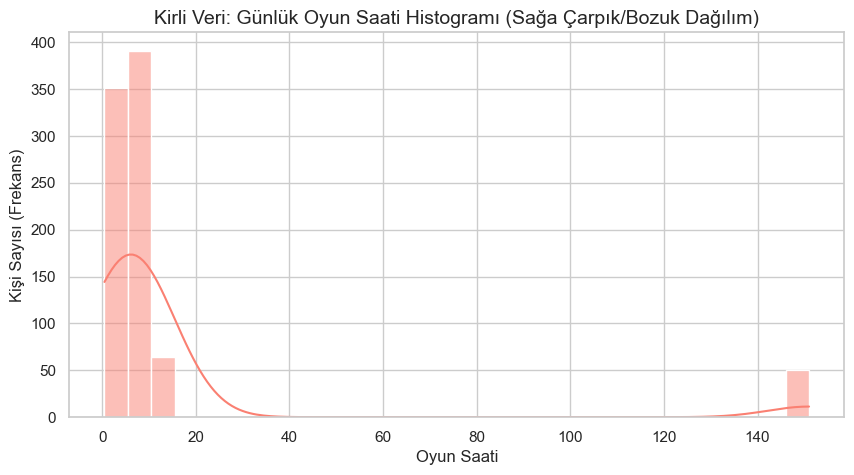

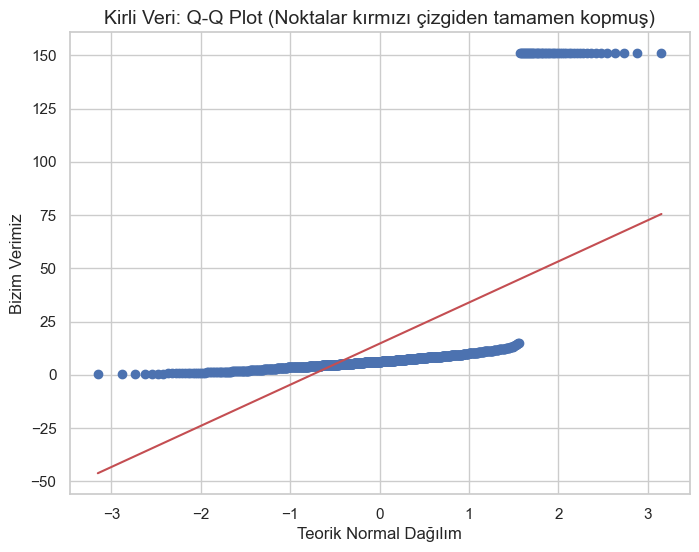

In [7]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


# Grafiklerimizin daha şık görünmesi için bir tema seçiyoruz
sns.set_theme(style="whitegrid")

print("--- ADIM 2: KİRLİ VERİNİN KEŞİFÇİ VERİ ANALİZİ (EDA) ---")

# 1. GRAFİK: Eksik Verilerin (NaN) Haritası
plt.figure(figsize=(12, 6))
# Bu kod, verideki boşlukları sarı çizgiler olarak çizer
sns.heatmap(df_kirli.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Kirli Veri Setindeki Eksik (NaN) Değerlerin Dağılımı (Sarı Çizgiler = Boşluklar)', fontsize=14)
plt.show()

# 2. GRAFİK: Yaş Sütunundaki Uç Değerleri (Outliers) Gösterme
plt.figure(figsize=(10, 5))
# Kutu grafiği (Boxplot) uç değerleri bulmak için en iyi yöntemdir
sns.boxplot(x=df_kirli['age'], color='lightcoral')
plt.title('Yaş (Age) Sütunundaki Uç Değerler (Aşırı Yüksek Yaşlar)', fontsize=14)
plt.xlabel('Yaş')
plt.show()

# 3. GRAFİK: Günlük Oyun Saati Sütunundaki Uç Değerleri Gösterme
plt.figure(figsize=(10, 5))      
sns.boxplot(x=df_kirli['daily_gaming_hours'], color='skyblue')
plt.title('Günlük Oyun Saati Sütunundaki İmkansız Uç Değerler', fontsize=14)
plt.xlabel('Oyun Saati (Saat)')
plt.show()

print("\n--- NORMAL DAĞILIM KONTROLÜ (KİRLİ VERİ) ---")

# 1. HİSTOGRAM VE ÇAN EĞRİSİ (KDE)
plt.figure(figsize=(10, 5))
# kde=True parametresi, çubukların üzerine o meşhur çan eğrisi çizgisini çeker
sns.histplot(df_kirli['daily_gaming_hours'], bins=30, kde=True, color='salmon')
plt.title('Kirli Veri: Günlük Oyun Saati Histogramı (Sağa Çarpık/Bozuk Dağılım)', fontsize=14)
plt.xlabel('Oyun Saati')
plt.ylabel('Kişi Sayısı (Frekans)')
plt.show()

# 2. Q-Q PLOT (KANTİL-KANTİL GRAFİĞİ) - Hocanın beklediği asıl grafik!
plt.figure(figsize=(8, 6))
# probplot komutu verimizi alır ve ideal bir normal dağılım çizgisiyle (kırmızı çizgi) kıyaslar
stats.probplot(df_kirli['daily_gaming_hours'].dropna(), dist="norm", plot=plt)
plt.title('Kirli Veri: Q-Q Plot (Noktalar kırmızı çizgiden tamamen kopmuş)', fontsize=14)
plt.xlabel('Teorik Normal Dağılım')
plt.ylabel('Bizim Verimiz')
plt.show()

In [3]:
import pandas as pd
import numpy as np

print("--- ADIM 3: VERİ TEMİZLEME VE ÖN İŞLEME (TEDAVİ) ---")

# Kirli verimizin orijinalini bozmamak için bir kopyasını alıp onun üzerinde çalışıyoruz
df_temiz = df_kirli.copy()

# ---------------------------------------------------------
# 1. YAZIM HATALARINI (TUTARSIZLIKLARI) DÜZELTME
# ---------------------------------------------------------
# C adımında eklediğimiz 'BOZUK_VERI_999' yazılarını bulup, onları istatistiksel 
# olarak doldurabilmek için standart boşluğa (NaN) çeviriyoruz.
df_temiz = df_temiz.replace('BOZUK_VERI_999', np.nan)


# ---------------------------------------------------------
# 2. EKSİK VERİLERİ (NaN) DOLDURMA (Imputation)
# ---------------------------------------------------------
# Sayısal Sütunlar: Neden Ortalama (Mean) değil de Medyan (Ortanca) kullanıyoruz?
# Çünkü verimizde aşırı uç değerler var! Uç değerler ortalamayı bozar ama medyanı etkilemez.
sayisal_sutunlar = df_temiz.select_dtypes(include=[np.number]).columns
for col in sayisal_sutunlar:
    medyan_degeri = df_temiz[col].median()
    df_temiz[col] = df_temiz[col].fillna(medyan_degeri)

# Kategorik (Yazı) Sütunlar: Mod (En çok tekrar eden değer) ile dolduruyoruz.
kategorik_sutunlar = df_temiz.select_dtypes(include=['object']).columns
for col in kategorik_sutunlar:
    mod_degeri = df_temiz[col].mode()[0]
    df_temiz[col] = df_temiz[col].fillna(mod_degeri)


# ---------------------------------------------------------
# 3. UÇ DEĞERLERİ (OUTLIERS) IQR YÖNTEMİYLE BASKILAMA (Capping)
# ---------------------------------------------------------
# Bu fonksiyon istatistiğin altın kuralı olan Çeyrekler Açıklığı (IQR) yöntemini kullanır.
def uclari_baskila(dataframe, sutun):
    Q1 = dataframe[sutun].quantile(0.25) # Verinin %25'lik sınırı
    Q3 = dataframe[sutun].quantile(0.75) # Verinin %75'lik sınırı
    IQR = Q3 - Q1                        # Orta %50'lik kutunun boyutu
    
    # Alt ve Üst sınırları belirliyoruz (İstatistiksel Formül)
    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR
    
    # Sınırı aşan anormal değerleri silmek yerine, onları tam sınır değerine eşitliyoruz (Baskılama)
    dataframe[sutun] = np.where(dataframe[sutun] > ust_sinir, ust_sinir, dataframe[sutun])
    dataframe[sutun] = np.where(dataframe[sutun] < alt_sinir, alt_sinir, dataframe[sutun])
    return dataframe

# Baskılama işlemini tüm sayısal sütunlara uyguluyoruz
for col in sayisal_sutunlar:
    df_temiz = uclari_baskila(df_temiz, col)

# ---------------------------------------------------------
print("İşlem Başarılı! Hastamız tamamen iyileşti.")
print(f"Kalan Toplam Eksik Veri Sayısı: {df_temiz.isnull().sum().sum()}")

--- ADIM 3: VERİ TEMİZLEME VE ÖN İŞLEME (TEDAVİ) ---
İşlem Başarılı! Hastamız tamamen iyileşti.
Kalan Toplam Eksik Veri Sayısı: 0


--- ADIM 4: TEMİZLENMİŞ VERİNİN GÖRSEL KANITI (SONUÇ) ---


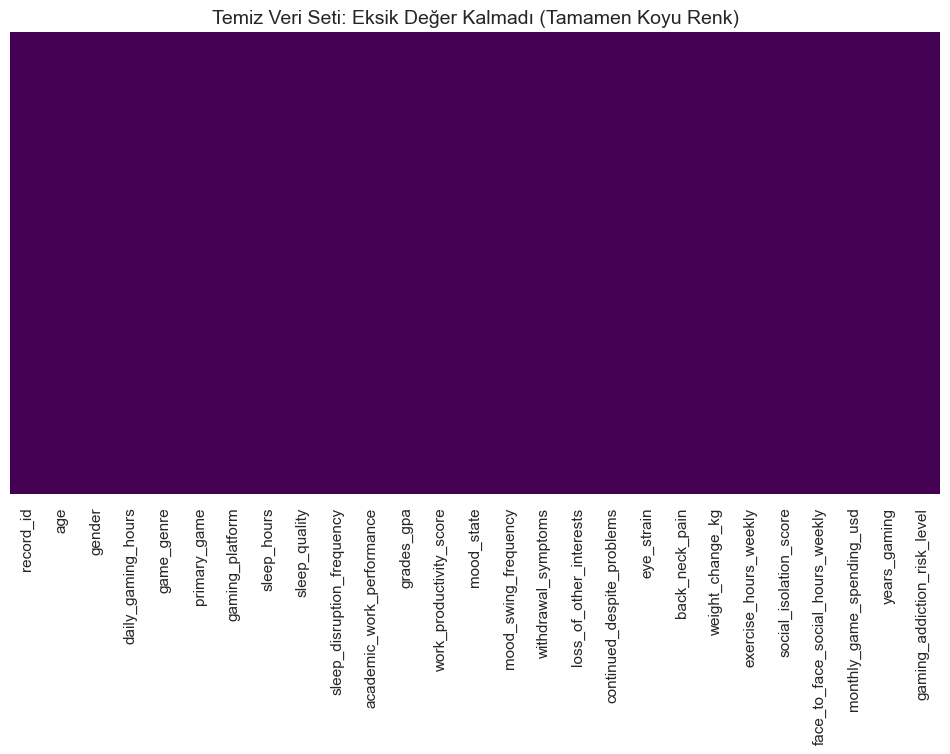

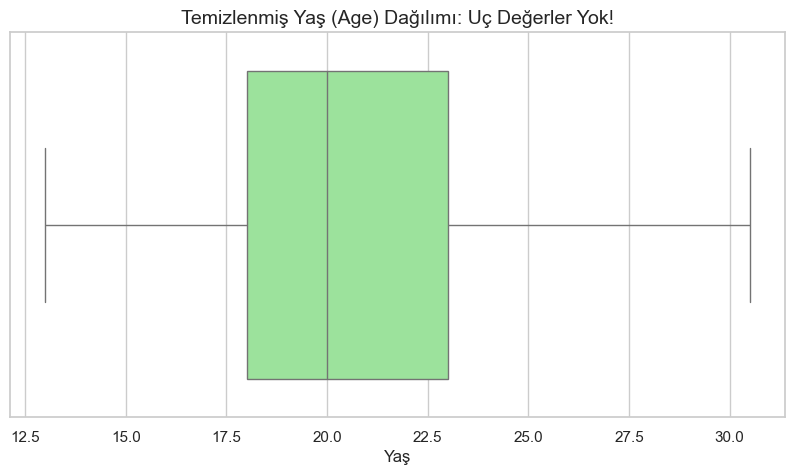

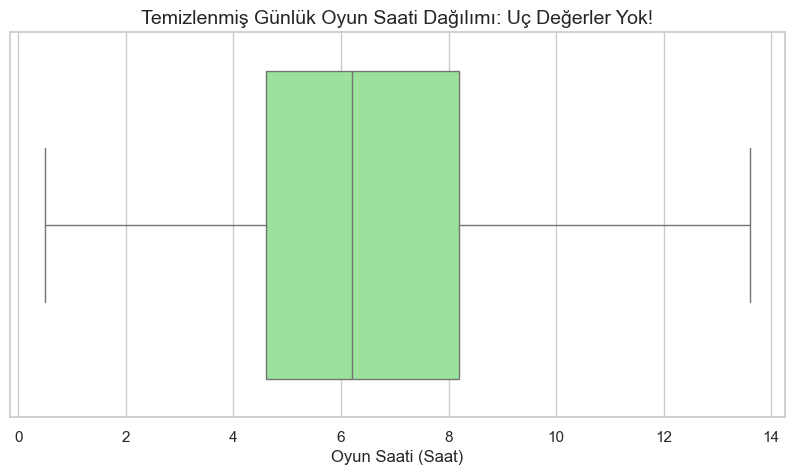


--- NORMAL DAĞILIM KONTROLÜ (TEMİZ VERİ) ---


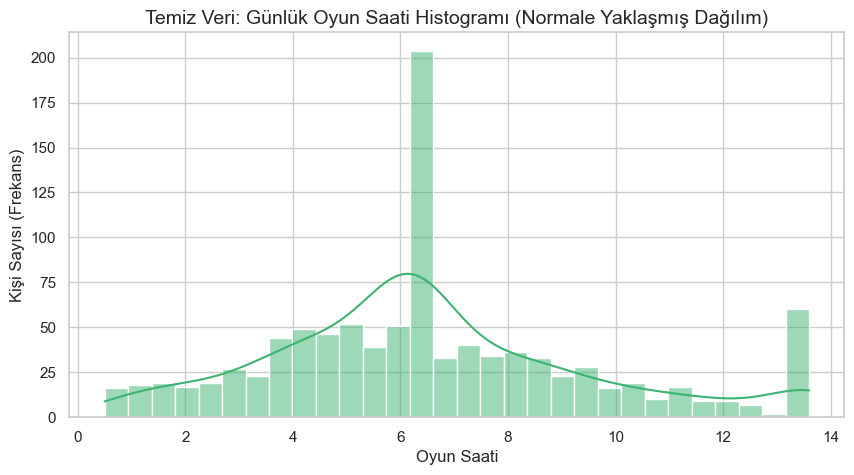

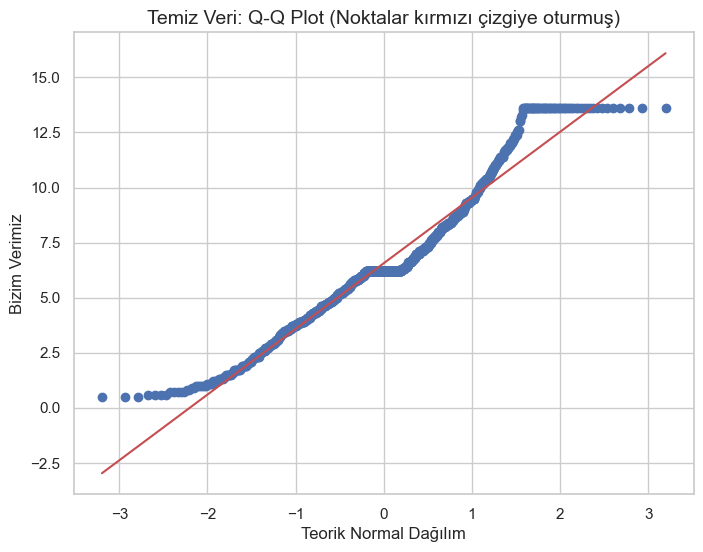

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ADIM 4: TEMİZLENMİŞ VERİNİN GÖRSEL KANITI (SONUÇ) ---")

# 1. GRAFİK: Temizlenmiş Veride Eksik Veri (NaN) Haritası
plt.figure(figsize=(12, 6))
sns.heatmap(df_temiz.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Temiz Veri Seti: Eksik Değer Kalmadı (Tamamen Koyu Renk)', fontsize=14)
plt.show()

# 2. GRAFİK: Yaş (Age) Sütunu Kutu Grafiği (Uç değerleri tıraşlanmış)
plt.figure(figsize=(10, 5))

sns.boxplot(x=df_temiz['age'], color='lightgreen') 
plt.title('Temizlenmiş Yaş (Age) Dağılımı: Uç Değerler Yok!', fontsize=14)
plt.xlabel('Yaş')
plt.show()

# 3. GRAFİK: Oyun Saati Sütunu Kutu Grafiği (Uç değerleri tıraşlanmış)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_temiz['daily_gaming_hours'], color='lightgreen')
plt.title('Temizlenmiş Günlük Oyun Saati Dağılımı: Uç Değerler Yok!', fontsize=14)
plt.xlabel('Oyun Saati (Saat)')
plt.show()

print("\n--- NORMAL DAĞILIM KONTROLÜ (TEMİZ VERİ) ---")

# 1. HİSTOGRAM VE ÇAN EĞRİSİ (KDE) - TEMİZ
plt.figure(figsize=(10, 5))
sns.histplot(df_temiz['daily_gaming_hours'], bins=30, kde=True, color='mediumseagreen')
plt.title('Temiz Veri: Günlük Oyun Saati Histogramı (Normale Yaklaşmış Dağılım)', fontsize=14)
plt.xlabel('Oyun Saati')
plt.ylabel('Kişi Sayısı (Frekans)')
plt.show()

# 2. Q-Q PLOT (KANTİL-KANTİL GRAFİĞİ) - TEMİZ
plt.figure(figsize=(8, 6))
stats.probplot(df_temiz['daily_gaming_hours'], dist="norm", plot=plt)
plt.title('Temiz Veri: Q-Q Plot (Noktalar kırmızı çizgiye oturmuş)', fontsize=14)
plt.xlabel('Teorik Normal Dağılım')
plt.ylabel('Bizim Verimiz')
plt.show()

In [ ]:
from scipy import stats
import pandas as pd

print("--- ADIM 5: İSTATİSTİKSEL HİPOTEZ TESTLERİ ---")

# ==============================================================================
# HİPOTEZ 1: İki Bağımsız Örneklem T-Testi (Independent T-Test)
# Soru: "asosyallik (Withdrawal Symptoms)" yaşayanlar ile yaşamayanların 
#       "Sosyal İzolasyon Skorları (Social Isolation Score)" arasında anlamlı bir fark var mıdır?
# ==============================================================================
print("\n--- HİPOTEZ 1: asosyallik belirtisi ve Sosyal İzolasyon (T-Testi) ---")

# Grupları ayırıyoruz
asosyaly = df_temiz[df_temiz['withdrawal_symptoms'] == True]['social_isolation_score']
asosyaln = df_temiz[df_temiz['withdrawal_symptoms'] == False]['social_isolation_score']

# T-Testini uyguluyoruz
t_istatistigi, p_degeri_1 = stats.ttest_ind(asosyaly, asosyaln)

print(f"P-Değeri: {p_degeri_1:.5f}")
if p_degeri_1 < 0.05:
    print("Sonuç: H0 REDDEDİLDİ. asosyallik yaşayanlar ile yaşamayanların sosyal izolasyon skorları arasında istatistiksel olarak ANLAMLI BİR FARK VARDIR.")
else:
    print("Sonuç: H0 KABUL EDİLDİ. İki grup arasında anlamlı bir FARK YOKTUR.")


# ==============================================================================
# HİPOTEZ 2: Tek Yönlü Varyans Analizi (One-Way ANOVA)
# Soru: Farklı "Oyun Türlerini (Game Genre)" oynayanların "Günlük Oyun Saatleri" 
#       arasında istatistiksel olarak anlamlı bir fark var mıdır?
# ==============================================================================
print("\n--- HİPOTEZ 2: Oyun Türü ve Günlük Oyun Saati (ANOVA) ---")

# Verimizdeki oyun türlerini bulup gruplara ayırıyoruz (Örn: RPG, FPS, MOBA vs.)
oyun_turleri = df_temiz['game_genre'].unique()
grup_verileri = [df_temiz[df_temiz['game_genre'] == tur]['daily_gaming_hours'] for tur in oyun_turleri]

# ANOVA testini uyguluyoruz (*grup_verileri liste içindeki tüm grupları teste sokar)
f_istatistigi, p_degeri_2 = stats.f_oneway(*grup_verileri)

print(f"P-Değeri: {p_degeri_2:.5f}")
if p_degeri_2 < 0.05:
    print("Sonuç: H0 REDDEDİLDİ. Farklı oyun türlerini oynayanların günlük oyun saatleri arasında ANLAMLI BİR FARK VARDIR.")
else:
    print("Sonuç: H0 KABUL EDİLDİ. Oyun türünün günlük oyun saatine anlamlı bir ETKİSİ YOKTUR.")


# ==============================================================================
# HİPOTEZ 3: Ki-Kare Bağımsızlık Testi (Chi-Square Test)
# Soru: "Cinsiyet (Gender)" ile "Oyun Bağımlılığı Risk Seviyesi (Gaming Addiction Risk Level)" 
#       birbirinden bağımsız mıdır, yoksa aralarında bir ilişki var mıdır?
# ==============================================================================
print("\n--- HİPOTEZ 3: Cinsiyet ve Bağımlılık Riski (Ki-Kare Testi) ---")

# İki kategorik (yazı) değişkeni karşılaştırmak için önce Çapraz Tablo (Crosstab) oluşturmalıyız
capraz_tablo = pd.crosstab(df_temiz['gender'], df_temiz['gaming_addiction_risk_level'])

# Ki-Kare testini uyguluyoruz
chi2, p_degeri_3, serbestlik_derecesi, beklenen_frekanslar = stats.chi2_contingency(capraz_tablo)

print(f"P-Değeri: {p_degeri_3:.5f}")
if p_degeri_3 < 0.05:
    print("Sonuç: H0 REDDEDİLDİ. Cinsiyet ile oyun bağımlılığı riski arasında istatistiksel olarak ANLAMLI BİR İLİŞKİ VARDIR (Bağımlıdırlar).")
else:
    print("Sonuç: H0 KABUL EDİLDİ. Cinsiyet ile bağımlılık riski arasında bir İLİŞKİ YOKTUR (Bağımsızdırlar).")

--- ADIM 5: İSTATİSTİKSEL HİPOTEZ TESTLERİ ---

--- HİPOTEZ 1: Yoksunluk Belirtisi ve Sosyal İzolasyon (T-Testi) ---
P-Değeri: 0.00000
Sonuç: H0 REDDEDİLDİ. Yoksunluk belirtisi yaşayanlar ile yaşamayanların sosyal izolasyon skorları arasında istatistiksel olarak ANLAMLI BİR FARK VARDIR.

--- HİPOTEZ 2: Oyun Türü ve Günlük Oyun Saati (ANOVA) ---
P-Değeri: 0.05016
Sonuç: H0 KABUL EDİLDİ. Oyun türünün günlük oyun saatine anlamlı bir ETKİSİ YOKTUR.

--- HİPOTEZ 3: Cinsiyet ve Bağımlılık Riski (Ki-Kare Testi) ---
P-Değeri: 0.61585
Sonuç: H0 KABUL EDİLDİ. Cinsiyet ile bağımlılık riski arasında bir İLİŞKİ YOKTUR (Bağımsızdırlar).


In [6]:
from scipy import stats

print("--- ADIM 6: İLERİ DÜZEY İSTATİSTİKSEL ANALİZLER ---")

# ==============================================================================
# HİPOTEZ 4: Pearson Korelasyon Analizi
# Soru: "Günlük Oyun Saati (daily_gaming_hours)" ile "Uyku Saati (sleep_hours)" 
#       arasında istatistiksel olarak anlamlı bir ilişki var mıdır?
# ==============================================================================
print("\n--- HİPOTEZ 4: Oyun Saati ve Uyku Saati (Korelasyon) ---")

# İki sayısal sütunu alıyoruz
oyun_saati = df_temiz['daily_gaming_hours']
uyku_saati = df_temiz['sleep_hours']

# Pearson Korelasyon testini uyguluyoruz
r_katsayisi, p_degeri_4 = stats.pearsonr(oyun_saati, uyku_saati)

print(f"Korelasyon Katsayısı (r): {r_katsayisi:.3f}")
print(f"P-Değeri: {p_degeri_4:.5f}")

 # 1. Aşama: Aralarında gerçekten anlamlı bir ilişki var mı? (P-değeri kontrolü)
#if p_degeri_4 < 0.05:
    
    # 2. Aşama: Madem ilişki var, peki bu ilişkinin YÖNÜ ne? (Korelasyon katsayısı kontrolü)
    #if r_katsayisi > 0:
       # print("Sonuç: H0 REDDEDİLDİ.")
        #print("İstatistiksel Yorum: İki değişken arasında anlamlı ve POZİTİF (+) yönde bir ilişki VARDIR.")
        #print("Gerçek Hayat Yorumu: Yani günlük oyun saati ARTTIKÇA, uyku saati de ARTMAKTADIR.")
        
    #elif r_katsayisi < 0:
     #   print("Sonuç: H0 REDDEDİLDİ.")
      #  print("İstatistiksel Yorum: İki değişken arasında anlamlı ve NEGATİF (-) yönde bir ilişki VARDIR.")
       # print("Gerçek Hayat Yorumu: Yani günlük oyun saati ARTTIKÇA, uyku saati AZALMAKTADIR.")

# Eğer p-değeri 0.05'ten büyük çıkarsa:
#else:
 #   print("Sonuç: H0 KABUL EDİLDİ.")
  #  print("İstatistiksel Yorum: İki değişken arasında anlamlı bir korelasyon (ilişki) YOKTUR.")
   # print("Gerçek Hayat Yorumu: Yani oyun saatinin artması veya azalması, uyku saatini belirgin bir şekilde etkilememektedir.") 

if p_degeri_4 < 0.05:
    yon = "NEGATİF" if r_katsayisi < 0 else "POZİTİF"
    print(f"Sonuç: H0 REDDEDİLDİ. İki değişken arasında istatistiksel olarak anlamlı, {yon} yönde bir ilişki VARDIR.")
else:
    print("Sonuç: H0 KABUL EDİLDİ. İki değişken arasında anlamlı bir korelasyon YOKTUR.")


# ==============================================================================
# HİPOTEZ 5: Basit Doğrusal Regresyon (Tahmin Modeli)
# Soru: "Günlük Oyun Saatini (X)" bilirsek, o kişinin "Uyku Saatini (Y)" tahmin 
#       edebilir miyiz? Oyun saati, uyku saatini ne kadar etkiliyor?
# ==============================================================================
print("\n--- HİPOTEZ 5: Oyun Saatinin Uyku Saatini Tahmin Etmesi (Regresyon) ---")

# linregress komutu bize regresyon formülündeki tüm parçaları verir
regresyon = stats.linregress(x=oyun_saati, y=uyku_saati)

# Formül parçalarını alıyoruz
egim_b1 = regresyon.slope       # Beta 1 (Eğim)
kesim_b0 = regresyon.intercept  # Beta 0 (Başlangıç noktası)
p_degeri_5 = regresyon.pvalue

print(f"Regresyon Denklemi: Uyku Saati = {kesim_b0:.2f} + ({egim_b1:.2f} * Oyun Saati)")
print(f"P-Değeri: {p_degeri_5:.5f}")

if p_degeri_5 < 0.05:
    print(f"Sonuç: Model ANLAMLI. Oyun saatindeki her 1 saatlik artış, uyku saatini {egim_b1:.2f} saat etkilemektedir.")
else:
    print("Sonuç: Model ANLAMSIZ. Oyun saatine bakarak uyku saatini istatistiksel olarak tahmin edemeyiz.")

--- ADIM 6: İLERİ DÜZEY İSTATİSTİKSEL ANALİZLER ---

--- HİPOTEZ 4: Oyun Saati ve Uyku Saati (Korelasyon) ---
Korelasyon Katsayısı (r): -0.441
P-Değeri: 0.00000
Sonuç: H0 REDDEDİLDİ. İki değişken arasında istatistiksel olarak anlamlı, NEGATİF yönde bir ilişki VARDIR.

--- HİPOTEZ 5: Oyun Saatinin Uyku Saatini Tahmin Etmesi (Regresyon) ---
Regresyon Denklemi: Uyku Saati = 7.25 + (-0.21 * Oyun Saati)
P-Değeri: 0.00000
Sonuç: Model ANLAMLI. Oyun saatindeki her 1 saatlik artış, uyku saatini -0.21 saat etkilemektedir.
